# 傾向スコアを用いた因果推論（401kデータ）

401(k)適格性が純金融資産に与える効果を、傾向スコアを用いて推定する。

## Step 0: 環境構築・データ読み込み

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wooldridge
from sklearn.linear_model import LogisticRegression

plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [2]:
df_org = wooldridge.data('401ksubs')

print(f"Shape: {df_org.shape}")
print(f"Missing values:\n{df_org.isnull().sum()}")
df_org.head()

Shape: (9275, 11)
Missing values:
e401k     0
inc       0
marr      0
male      0
age       0
fsize     0
nettfa    0
p401k     0
pira      0
incsq     0
agesq     0
dtype: int64


,e401k,inc,marr,male,age,fsize,nettfa,p401k,pira,incsq,agesq
0,0,13.170000,0,0,40,1,4.575000,0,1,173.448898,1600
1,1,61.230000,0,1,35,1,154.000000,1,0,3749.112793,1225
2,0,12.858000,1,0,44,2,0.000000,0,0,165.328156,1936
3,0,98.879997,1,1,44,2,21.799999,0,0,9777.253906,1936
4,0,22.614000,0,0,53,1,18.450001,0,0,511.393005,2809


### 分析用データの準備

- 処置変数: `e401k`（401(k)適格性）
- アウトカム: `nettfa`（純金融資産, $1,000単位）
- 共変量: `inc`, `marr`, `male`, `age`, `fsize`, `incsq`, `agesq`

In [3]:
treatment_col = 'e401k'
outcome_col = 'nettfa'
covariates = ['inc', 'marr', 'male', 'age', 'fsize', 'incsq', 'agesq']

df_analysis = df_org[[treatment_col, outcome_col] + covariates].copy()

print(f"Treated (e401k=1): {df_analysis[treatment_col].sum()}")
print(f"Control (e401k=0): {(df_analysis[treatment_col] == 0).sum()}")
print(f"Total: {len(df_analysis)}")

Treated (e401k=1): 3637
Control (e401k=0): 5638
Total: 9275


### Naive推定（未調整の差分）

In [4]:
y_treat_naive = df_analysis[df_analysis[treatment_col] == 1][outcome_col]
y_control_naive = df_analysis[df_analysis[treatment_col] == 0][outcome_col]

naive_effect = y_treat_naive.mean() - y_control_naive.mean()

print(f"Mean nettfa (Treated): ${y_treat_naive.mean():.2f}k")
print(f"Mean nettfa (Control): ${y_control_naive.mean():.2f}k")
print(f"Naive Effect: ${naive_effect:.2f}k")

Mean nettfa (Treated): $30.54k
Mean nettfa (Control): $11.68k
Naive Effect: $18.86k


## Step 1: 探索的データ分析（EDA）

### 基本統計量の比較

In [5]:
df_treat = df_analysis[df_analysis[treatment_col] == 1]
df_control = df_analysis[df_analysis[treatment_col] == 0]

stats_treat = df_treat[covariates].describe().T[['mean', 'std']]
stats_control = df_control[covariates].describe().T[['mean', 'std']]

stats_treat.columns = ['mean_treat', 'std_treat']
stats_control.columns = ['mean_control', 'std_control']

df_stats = pd.concat([stats_treat, stats_control], axis=1)
df_stats

,mean_treat,std_treat,mean_control,std_control
inc,47.297809,25.620004,34.066099,21.510636
marr,0.677206,0.467609,0.597198,0.490505
male,0.190542,0.392782,0.213374,0.409726
age,41.484465,9.605193,40.819440,10.716335
fsize,2.907891,1.477010,2.870344,1.556472
incsq,2893.286872,3486.962643,1623.124488,2519.085956
agesq,1813.195216,834.084594,1781.046116,933.066032


### 標準化平均差（SMD）の算出

$$
SMD = \frac{\bar{X}_{treat} - \bar{X}_{control}}{\sqrt{(s^2_{treat} + s^2_{control})/2}}
$$

目安: |SMD| < 0.1 でバランス良好

In [6]:
def calculate_smd(df, covariates, treatment_col='e401k'):
    df_treat = df[df[treatment_col] == 1]
    df_control = df[df[treatment_col] == 0]
    smd_dict = {}
    for cov in covariates:
        mean_treat = df_treat[cov].mean()
        mean_control = df_control[cov].mean()
        pooled_std = np.sqrt((df_treat[cov].var() + df_control[cov].var()) / 2)
        smd_dict[cov] = (mean_treat - mean_control) / pooled_std
    return pd.Series(smd_dict)

In [7]:
smd_before = calculate_smd(df_analysis, covariates)
df_smd = pd.DataFrame({'SMD_before': smd_before})
df_smd

,SMD_before
inc,0.559369
marr,0.166966
male,-0.056889
age,0.065353
fsize,0.024747
incsq,0.417574
agesq,0.036328


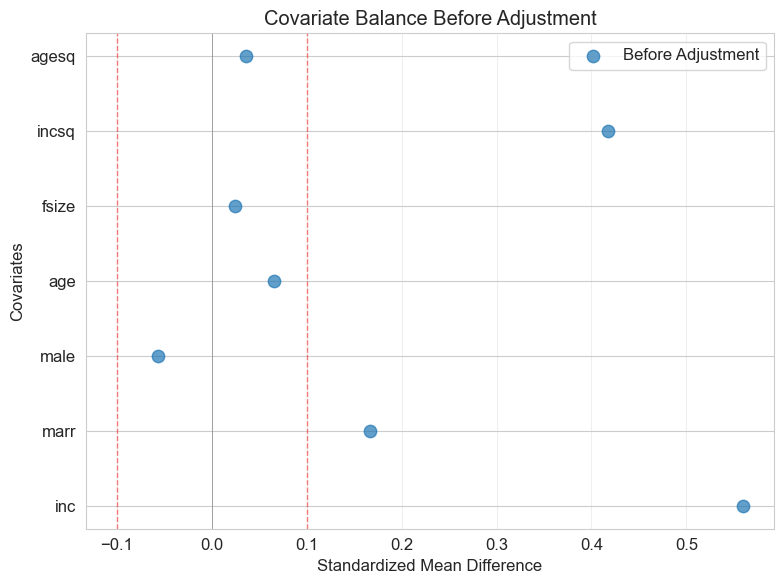

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(smd_before, range(len(smd_before)), s=80, alpha=0.7, label='Before Adjustment')
ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=-0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

ax.set_yticks(range(len(smd_before)))
ax.set_yticklabels(smd_before.index)
ax.set_xlabel('Standardized Mean Difference')
ax.set_ylabel('Covariates')
ax.set_title('Covariate Balance Before Adjustment')
ax.legend()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Step 2: 傾向スコアの推定

### ロジスティック回帰による傾向スコアの推定

In [9]:
X = df_analysis[covariates]
y = df_analysis[treatment_col]

model_ps = LogisticRegression(max_iter=1000, random_state=42)
model_ps.fit(X, y)

df_analysis['propensity_score'] = model_ps.predict_proba(X)[:, 1]

df_analysis.groupby(treatment_col)['propensity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
e401k,,,,,,,,
0,5638.0,0.354286,0.14428,0.071693,0.236948,0.323041,0.44888,0.748563
1,3637.0,0.450794,0.14589,0.125158,0.331205,0.449375,0.57424,0.752704


### 傾向スコアの分布の可視化

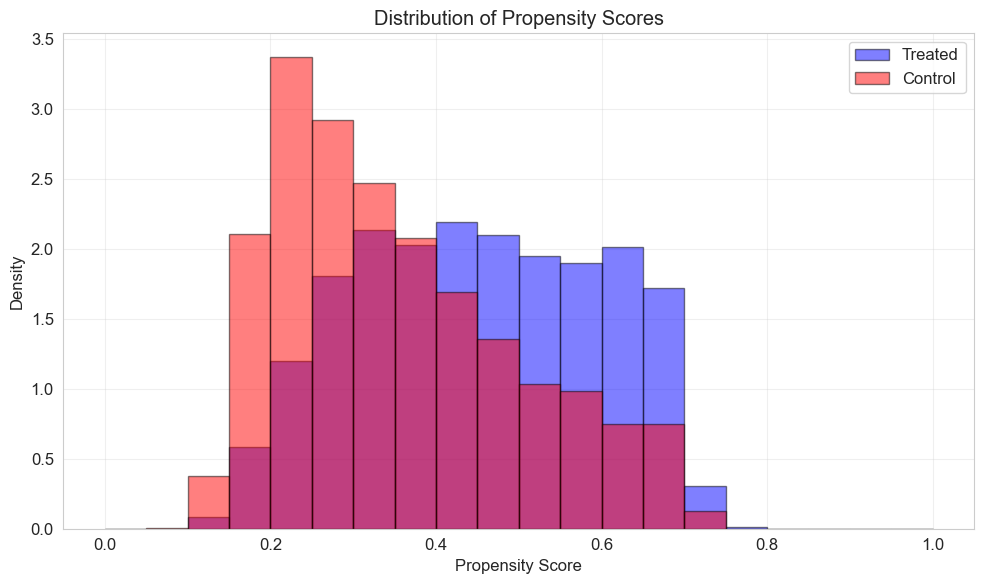

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(0, 1.05, 0.05)

ax.hist(df_analysis[df_analysis[treatment_col] == 1]['propensity_score'],
        bins=bins, alpha=0.5, label='Treated', color='blue', edgecolor='black', density=True)
ax.hist(df_analysis[df_analysis[treatment_col] == 0]['propensity_score'],
        bins=bins, alpha=0.5, label='Control', color='red', edgecolor='black', density=True)

ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Distribution of Propensity Scores')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 共通サポート仮定の確認

In [11]:
bins_check = np.arange(0, 1.05, 0.05)
df_analysis['ps_bin'] = pd.cut(df_analysis['propensity_score'], bins=bins_check)

overlap_check = df_analysis.groupby(['ps_bin', treatment_col]).size().unstack(fill_value=0)
overlap_check['both_present'] = (overlap_check[0] > 0) & (overlap_check[1] > 0)

print(f"Bins with both groups: {overlap_check['both_present'].sum()} / {len(overlap_check)}")
overlap_check

Bins with both groups: 13 / 15


e401k,0,1,both_present
ps_bin,,,
"(0.05, 0.1]",2,0,False
"(0.1, 0.15]",107,15,True
"(0.15, 0.2]",593,106,True
"(0.2, 0.25]",950,218,True
"(0.25, 0.3]",822,328,True
"(0.3, 0.35]",697,388,True
"(0.35, 0.4]",586,368,True
"(0.4, 0.45]",476,399,True
"(0.45, 0.5]",381,381,True


## Step 3: バランシングの確認

IPW重みを使って共変量バランスの改善を確認

### IPW重みの計算

In [12]:
df_analysis['ipw_weight'] = np.where(
    df_analysis[treatment_col] == 1,
    1 / df_analysis['propensity_score'],
    1 / (1 - df_analysis['propensity_score'])
)

df_analysis.groupby(treatment_col)['ipw_weight'].describe()

,count,mean,std,min,25%,50%,75%,max
e401k,,,,,,,,
0,5638.0,1.653289,0.488327,1.077229,1.310527,1.477194,1.814488,3.97714
1,3637.0,2.524675,1.028915,1.328543,1.741432,2.225313,3.019281,7.98992


### IPW調整後のSMDを算出

In [13]:
def calculate_weighted_smd(df, covariates, treatment_col='e401k', weight_col='ipw_weight'):
    df_treat = df[df[treatment_col] == 1]
    df_control = df[df[treatment_col] == 0]
    smd_dict = {}
    for cov in covariates:
        mean_treat = np.average(df_treat[cov], weights=df_treat[weight_col])
        mean_control = np.average(df_control[cov], weights=df_control[weight_col])
        var_treat = np.average((df_treat[cov] - mean_treat)**2, weights=df_treat[weight_col])
        var_control = np.average((df_control[cov] - mean_control)**2, weights=df_control[weight_col])
        pooled_std = np.sqrt((var_treat + var_control) / 2)
        smd_dict[cov] = (mean_treat - mean_control) / pooled_std
    return pd.Series(smd_dict)

smd_after = calculate_weighted_smd(df_analysis, covariates)

df_smd['SMD_after'] = smd_after
df_smd

,SMD_before,SMD_after
inc,0.559369,0.012912
marr,0.166966,0.004930
male,-0.056889,-0.005591
age,0.065353,-0.001688
fsize,0.024747,-0.000621
incsq,0.417574,0.010390
agesq,0.036328,-0.002011


### Love Plot: 調整前後のSMDを比較

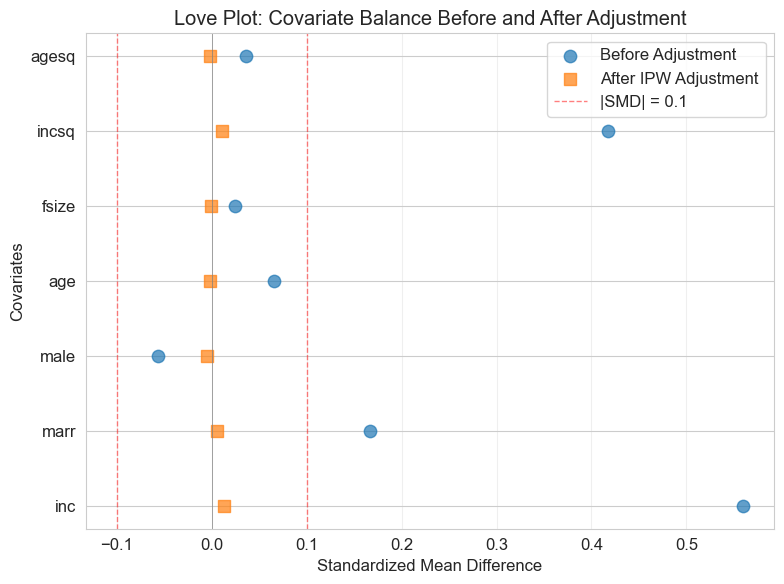

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(covariates))

ax.scatter(smd_before, y_pos, s=80, alpha=0.7, label='Before Adjustment', marker='o')
ax.scatter(smd_after, y_pos, s=80, alpha=0.7, label='After IPW Adjustment', marker='s')

ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='|SMD| = 0.1')
ax.axvline(x=-0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(covariates)
ax.set_xlabel('Standardized Mean Difference')
ax.set_ylabel('Covariates')
ax.set_title('Love Plot: Covariate Balance Before and After Adjustment')
ax.legend()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Step 4: 効果の推定

3つの手法（マッチング、層別解析、IPW）で処置効果を推定

### 手法1: 最近傍マッチング（ATT）

傾向スコアに基づいて各処置群ユニットに最も近い対照群ユニットをマッチング

In [15]:
def nearest_neighbor_matching(df, treatment_col='e401k', ps_col='propensity_score', outcome_col='nettfa'):
    df_treat = df[df[treatment_col] == 1].copy()
    df_control = df[df[treatment_col] == 0].copy()

    matched_pairs = []
    used_control_indices = set()

    for _, treat_row in df_treat.iterrows():
        available_control = df_control[~df_control.index.isin(used_control_indices)]
        if len(available_control) == 0:
            continue
        distances = np.abs(available_control[ps_col] - treat_row[ps_col])
        nearest_idx = distances.idxmin()
        matched_pairs.append({
            'treat_outcome': treat_row[outcome_col],
            'control_outcome': df_control.loc[nearest_idx, outcome_col],
        })
        used_control_indices.add(nearest_idx)

    return pd.DataFrame(matched_pairs)

df_matched = nearest_neighbor_matching(df_analysis)

att_matching = df_matched['treat_outcome'].mean() - df_matched['control_outcome'].mean()

print(f"Number of matched pairs: {len(df_matched)}")
print(f"ATT (Matching): ${att_matching:.2f}k")

Number of matched pairs: 3637
ATT (Matching): $14.83k


### 手法2: 層別解析（ATE）

傾向スコアによってサンプルを層に分割し、各層内で効果を推定

In [16]:
def stratification_estimator(df, treatment_col='e401k', ps_col='propensity_score',
                              outcome_col='nettfa', n_strata=5):
    df = df.copy()
    df['strata'] = pd.qcut(df[ps_col], q=n_strata, labels=False, duplicates='drop')

    strata_effects = []
    strata_sizes = []

    for stratum in sorted(df['strata'].unique()):
        df_stratum = df[df['strata'] == stratum]
        y_treat = df_stratum[df_stratum[treatment_col] == 1][outcome_col]
        y_control = df_stratum[df_stratum[treatment_col] == 0][outcome_col]
        if len(y_treat) > 0 and len(y_control) > 0:
            strata_effects.append(y_treat.mean() - y_control.mean())
            strata_sizes.append(len(df_stratum))

    return np.average(strata_effects, weights=strata_sizes)

ate_stratification = stratification_estimator(df_analysis)

print(f"ATE (Stratification): ${ate_stratification:.2f}k")

ATE (Stratification): $9.94k


### 手法3: 逆確率重み付け（IPW）

In [17]:
def ipw_estimator(df, treatment_col='e401k', weight_col='ipw_weight', outcome_col='nettfa'):
    df_treat = df[df[treatment_col] == 1]
    df_control = df[df[treatment_col] == 0]
    y_treat_weighted = np.average(df_treat[outcome_col], weights=df_treat[weight_col])
    y_control_weighted = np.average(df_control[outcome_col], weights=df_control[weight_col])
    return y_treat_weighted - y_control_weighted

ate_ipw = ipw_estimator(df_analysis)

print(f"ATE (IPW): ${ate_ipw:.2f}k")

ATE (IPW): $9.04k


## Step 5: 結果のまとめ

In [18]:
df_result = pd.DataFrame({
    'Method': ['Naive (unadj.)', 'Matching', 'Stratification', 'IPW'],
    'Estimand': ['-', 'ATT', 'ATE', 'ATE'],
    'Effect ($1,000)': [naive_effect, att_matching, ate_stratification, ate_ipw]
})

df_result

,Method,Estimand,"Effect ($1,000)"
0,Naive (unadj.),-,18.858320
1,Matching,ATT,14.828665
2,Stratification,ATE,9.942433
3,IPW,ATE,9.039486


## 考察: ATTとATEの差について

Matching（ATT: $14.83k）と Stratification/IPW（ATE: 約$9〜10k）の間には約$5kの差がある。
これは推定対象（estimand）の違いによって説明できる可能性が高い。

- **ATT（Average Treatment Effect on the Treated）**: 実際に401(k)に適格である層における効果
- **ATE（Average Treatment Effect）**: 適格・非適格を含む全体における効果

401(k)適格者は非適格者と比べて年収（`inc`）が高い傾向にある（平均$47.3k vs $34.1k）。
高所得層は貯蓄に回せる余裕が大きく、401(k)の税制優遇を活用して純金融資産をより大きく増やせると考えられる。
一方、401(k)に適格になることがほとんどないような低所得層まで含めて平均的な効果（ATE）を考えると、
仮に適格になったとしても貯蓄に回せる余裕が小さいため、効果は相対的に小さくなる。

つまり、**処置効果に異質性（heterogeneity）がある**場合、ATT > ATE となるのは整合的であり、
今回の結果はこの解釈と一致している。